In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("WARNING: GPU is not available.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8


In [3]:
import os
import json
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights,
    resnet50,
    ResNet50_Weights
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [6]:
import os
import random
import numpy as np

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split

In [7]:
DATA_DIR = "/content/drive/MyDrive/MediScan/data"

print("Data directory:", DATA_DIR)
print("Contents:", os.listdir(DATA_DIR))

Data directory: /content/drive/MyDrive/MediScan/data
Contents: ['Testing', 'Training', 'splits']


In [8]:
class_to_idx = {
    "glioma": 0,
    "meningioma": 1,
    "notumor": 2,
    "pituitary": 3
}

idx_to_class = {v: k for k, v in class_to_idx.items()}

print("Class Mapping")
print("=" * 40)

for class_name, class_id in class_to_idx.items():
    print(f"{class_id} → {class_name}")

Class Mapping
0 → glioma
1 → meningioma
2 → notumor
3 → pituitary


In [10]:
DATA_DIR = "/content/drive/MyDrive/MediScan/data"

import os

print("Data directory:")
print(DATA_DIR)

print("\nContents:")
for item in os.listdir(DATA_DIR):
    print(item)

Data directory:
/content/drive/MyDrive/MediScan/data

Contents:
Testing
Training
splits


In [11]:
import os

SPLITS_DIR = "/content/drive/MyDrive/MediScan/data/splits"

print("Splits directory:")
print(SPLITS_DIR)

print("\nContents:")
for item in os.listdir(SPLITS_DIR):
    print(item)

Splits directory:
/content/drive/MyDrive/MediScan/data/splits

Contents:
train.csv
validation.csv
test.csv


In [12]:
import pandas as pd
import os

SPLITS_DIR = "/content/drive/MyDrive/MediScan/data/splits"

train_df = pd.read_csv(os.path.join(SPLITS_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(SPLITS_DIR, "validation.csv"))
test_df = pd.read_csv(os.path.join(SPLITS_DIR, "test.csv"))

print("Existing Day 2 splits loaded successfully!")
print("=" * 50)

print("Training samples   :", len(train_df))
print("Validation samples :", len(val_df))
print("Testing samples    :", len(test_df))

Existing Day 2 splits loaded successfully!
Training samples   : 5040
Validation samples : 1080
Testing samples    : 1080


In [13]:
print("Train CSV columns:")
print(train_df.columns.tolist())

print("\nFirst 5 training rows:")
display(train_df.head())

Train CSV columns:
['split', 'class', 'filename', 'path']

First 5 training rows:


,split,class,filename,path
0,Training,notumor,Tr-no_1054.jpg,/content/drive/MyDrive/MediScan/data/Training/...
1,Testing,pituitary,Te-pi_20.jpg,/content/drive/MyDrive/MediScan/data/Testing/p...
2,Training,notumor,Tr-no_223.jpg,/content/drive/MyDrive/MediScan/data/Training/...
3,Training,pituitary,Tr-pi_835.jpg,/content/drive/MyDrive/MediScan/data/Training/...
4,Training,notumor,Tr-no_439.jpg,/content/drive/MyDrive/MediScan/data/Training/...


In [14]:
class_to_idx = {
    "glioma": 0,
    "meningioma": 1,
    "notumor": 2,
    "pituitary": 3
}

idx_to_class = {v: k for k, v in class_to_idx.items()}

print("Class Mapping")
print("=" * 40)

for class_name, class_id in class_to_idx.items():
    print(f"{class_id} → {class_name}")

Class Mapping
0 → glioma
1 → meningioma
2 → notumor
3 → pituitary


In [15]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [16]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class BrainTumorDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = row["path"]
        class_name = row["class"]

        image = Image.open(image_path).convert("RGB")

        label = class_to_idx[class_name]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [17]:
train_dataset = BrainTumorDataset(
    train_df,
    transform=train_transform
)

val_dataset = BrainTumorDataset(
    val_df,
    transform=test_transform
)

test_dataset = BrainTumorDataset(
    test_df,
    transform=test_transform
)

print("Datasets recreated successfully!")
print("=" * 50)

print("Training dataset   :", len(train_dataset))
print("Validation dataset :", len(val_dataset))
print("Testing dataset    :", len(test_dataset))

Datasets recreated successfully!
Training dataset   : 5040
Validation dataset : 1080
Testing dataset    : 1080


In [18]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Test DataLoader created successfully!")
print("=" * 50)

print("Testing samples:", len(test_dataset))
print("Testing batches:", len(test_loader))

Test DataLoader created successfully!
Testing samples: 1080
Testing batches: 34


In [19]:
images, labels = next(iter(test_loader))

print("Day 5 Test DataLoader Verification")
print("=" * 50)

print("Images shape :", images.shape)
print("Labels shape :", labels.shape)
print("Images dtype :", images.dtype)
print("Labels dtype :", labels.dtype)

print("\nPixel range:")
print("Min:", images.min().item())
print("Max:", images.max().item())

print("\nLabels:")
print(labels)

Day 5 Test DataLoader Verification
Images shape : torch.Size([32, 3, 224, 224])
Labels shape : torch.Size([32])
Images dtype : torch.float32
Labels dtype : torch.int64

Pixel range:
Min: 0.0
Max: 1.0

Labels:
tensor([1, 2, 0, 1, 0, 0, 0, 2, 0, 2, 3, 0, 2, 3, 0, 1, 2, 0, 2, 1, 1, 0, 3, 3,
        3, 3, 2, 0, 3, 0, 1, 1])


In [20]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# Load EfficientNet-B0 architecture
weights = EfficientNet_B0_Weights.DEFAULT

efficientnet = efficientnet_b0(weights=weights)

# Replace classifier for 4 classes
efficientnet.classifier[1] = nn.Linear(
    efficientnet.classifier[1].in_features,
    4
)

# Move model to device
efficientnet = efficientnet.to(device)

print("EfficientNet-B0 recreated successfully!")
print("Classifier:", efficientnet.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 99.9MB/s]


EfficientNet-B0 recreated successfully!
Classifier: Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)


In [21]:
EFFICIENTNET_PATH = (
    "/content/drive/MyDrive/MediScan/models/"
    "efficientnet_b0_best.pth"
)

checkpoint = torch.load(
    EFFICIENTNET_PATH,
    map_location=device
)

efficientnet.load_state_dict(checkpoint)

efficientnet.eval()

print("EfficientNet-B0 checkpoint loaded successfully!")
print("Model set to evaluation mode.")

EfficientNet-B0 checkpoint loaded successfully!
Model set to evaluation mode.


In [22]:
images, labels = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():
    outputs = efficientnet(images)

print("EfficientNet-B0 Checkpoint Verification")
print("=" * 50)

print("Input shape :", images.shape)
print("Output shape:", outputs.shape)
print("Output dtype:", outputs.dtype)

EfficientNet-B0 Checkpoint Verification
Input shape : torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 4])
Output dtype: torch.float32


In [23]:
def evaluate_model(model, test_loader, device):
    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predictions = torch.argmax(outputs, dim=1)

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    return np.array(all_labels), np.array(all_predictions)


efficientnet_true, efficientnet_pred = evaluate_model(
    efficientnet,
    test_loader,
    device
)

print("EfficientNet-B0 evaluation completed!")
print("=" * 50)

print("Total test samples :", len(efficientnet_true))
print("Predictions        :", len(efficientnet_pred))

EfficientNet-B0 evaluation completed!
Total test samples : 1080
Predictions        : 1080


In [25]:
class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

print("Class names defined successfully!")
print(class_names)

Class names defined successfully!
['glioma', 'meningioma', 'notumor', 'pituitary']


In [26]:
from sklearn.metrics import classification_report, accuracy_score

efficientnet_accuracy = accuracy_score(
    efficientnet_true,
    efficientnet_pred
)

efficientnet_report = classification_report(
    efficientnet_true,
    efficientnet_pred,
    target_names=class_names,
    digits=4
)

print("EfficientNet-B0 Test Evaluation")
print("=" * 60)

print(f"Test Accuracy: {efficientnet_accuracy * 100:.2f}%")

print("\nClassification Report")
print("-" * 60)
print(efficientnet_report)

EfficientNet-B0 Test Evaluation
Test Accuracy: 90.09%

Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

      glioma     0.9467    0.8556    0.8988       270
  meningioma     0.8169    0.8593    0.8375       270
     notumor     0.9072    0.9778    0.9412       270
   pituitary     0.9425    0.9111    0.9266       270

    accuracy                         0.9009      1080
   macro avg     0.9033    0.9009    0.9010      1080
weighted avg     0.9033    0.9009    0.9010      1080



In [27]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create confusion matrix
efficientnet_cm = confusion_matrix(
    efficientnet_true,
    efficientnet_pred
)

print("EfficientNet-B0 Confusion Matrix")
print("=" * 50)
print(efficientnet_cm)

EfficientNet-B0 Confusion Matrix
[[231  31   7   1]
 [ 12 232  15  11]
 [  1   2 264   3]
 [  0  19   5 246]]


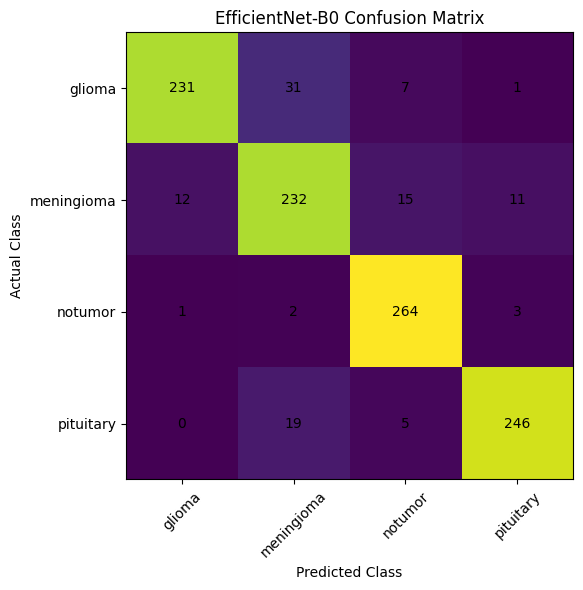

In [28]:
plt.figure(figsize=(7, 6))

plt.imshow(efficientnet_cm)

plt.title("EfficientNet-B0 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    range(len(class_names)),
    class_names
)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            efficientnet_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [29]:
efficientnet_results = {
    "model": "EfficientNet-B0",
    "test_samples": int(len(efficientnet_true)),
    "accuracy": float(efficientnet_accuracy),
    "confusion_matrix": efficientnet_cm.tolist()
}

RESULTS_DIR = "/content/drive/MyDrive/MediScan/results"

os.makedirs(RESULTS_DIR, exist_ok=True)

efficientnet_results_path = os.path.join(
    RESULTS_DIR,
    "efficientnet_b0_evaluation.json"
)

with open(efficientnet_results_path, "w") as f:
    json.dump(efficientnet_results, f, indent=4)

print("EfficientNet-B0 evaluation results saved!")
print(efficientnet_results_path)

EfficientNet-B0 evaluation results saved!
/content/drive/MyDrive/MediScan/results/efficientnet_b0_evaluation.json


In [30]:
from torchvision.models import resnet50, ResNet50_Weights
import torch.nn as nn

# Load pretrained ResNet50 architecture
weights = ResNet50_Weights.DEFAULT

resnet = resnet50(weights=weights)

# Replace final FC layer for 4 classes
resnet.fc = nn.Linear(
    resnet.fc.in_features,
    4
)

# Move model to GPU
resnet = resnet.to(device)

print("ResNet50 recreated successfully!")
print("FC Layer:", resnet.fc)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 136MB/s]


ResNet50 recreated successfully!
FC Layer: Linear(in_features=2048, out_features=4, bias=True)


In [31]:
RESNET_PATH = (
    "/content/drive/MyDrive/MediScan/models/"
    "resnet50_best.pth"
)

checkpoint = torch.load(
    RESNET_PATH,
    map_location=device
)

resnet.load_state_dict(checkpoint)

resnet.eval()

print("ResNet50 checkpoint loaded successfully!")
print("Model set to evaluation mode.")

ResNet50 checkpoint loaded successfully!
Model set to evaluation mode.


In [32]:
images, labels = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():
    outputs = resnet(images)

print("ResNet50 Checkpoint Verification")
print("=" * 50)

print("Input shape :", images.shape)
print("Output shape:", outputs.shape)
print("Output dtype:", outputs.dtype)

ResNet50 Checkpoint Verification
Input shape : torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 4])
Output dtype: torch.float32


In [33]:
resnet_true, resnet_pred = evaluate_model(
    resnet,
    test_loader,
    device
)

print("ResNet50 evaluation completed!")
print("=" * 50)

print("Total test samples :", len(resnet_true))
print("Predictions        :", len(resnet_pred))

ResNet50 evaluation completed!
Total test samples : 1080
Predictions        : 1080


In [34]:
from sklearn.metrics import classification_report, accuracy_score

resnet_accuracy = accuracy_score(
    resnet_true,
    resnet_pred
)

resnet_report = classification_report(
    resnet_true,
    resnet_pred,
    target_names=class_names,
    digits=4
)

print("ResNet50 Test Evaluation")
print("=" * 60)

print(f"Test Accuracy: {resnet_accuracy * 100:.2f}%")

print("\nClassification Report")
print("-" * 60)
print(resnet_report)

ResNet50 Test Evaluation
Test Accuracy: 89.26%

Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

      glioma     0.9137    0.8630    0.8876       270
  meningioma     0.8681    0.7556    0.8079       270
     notumor     0.9288    0.9667    0.9474       270
   pituitary     0.8608    0.9852    0.9188       270

    accuracy                         0.8926      1080
   macro avg     0.8929    0.8926    0.8904      1080
weighted avg     0.8929    0.8926    0.8904      1080



In [35]:
from sklearn.metrics import confusion_matrix

resnet_cm = confusion_matrix(
    resnet_true,
    resnet_pred
)

print("ResNet50 Confusion Matrix")
print("=" * 50)
print(resnet_cm)

ResNet50 Confusion Matrix
[[233  25   6   6]
 [ 20 204  13  33]
 [  2   3 261   4]
 [  0   3   1 266]]


In [36]:
resnet_results = {
    "model": "ResNet50",
    "test_samples": int(len(resnet_true)),
    "accuracy": float(resnet_accuracy),
    "confusion_matrix": resnet_cm.tolist()
}

RESNET_RESULTS_PATH = os.path.join(
    RESULTS_DIR,
    "resnet50_evaluation.json"
)

with open(RESNET_RESULTS_PATH, "w") as f:
    json.dump(resnet_results, f, indent=4)

print("ResNet50 evaluation results saved!")
print(RESNET_RESULTS_PATH)

ResNet50 evaluation results saved!
/content/drive/MyDrive/MediScan/results/resnet50_evaluation.json


In [37]:
comparison = {
    "EfficientNet-B0": {
        "Accuracy": efficientnet_accuracy * 100,
        "Macro F1": 0.9010 * 100
    },
    "ResNet50": {
        "Accuracy": resnet_accuracy * 100,
        "Macro F1": 0.8904 * 100
    }
}

print("MediScan — Model Comparison")
print("=" * 60)

print(f"{'Model':<20} {'Accuracy':>12} {'Macro F1':>12}")
print("-" * 60)

for model, metrics in comparison.items():
    print(
        f"{model:<20} "
        f"{metrics['Accuracy']:>11.2f}% "
        f"{metrics['Macro F1']:>11.2f}%"
    )

MediScan — Model Comparison
Model                    Accuracy     Macro F1
------------------------------------------------------------
EfficientNet-B0            90.09%       90.10%
ResNet50                   89.26%       89.04%


In [38]:
import os

RESULTS_DIR = "/content/drive/MyDrive/MediScan/results"

print("Files in results folder:")
print(os.listdir(RESULTS_DIR))

Files in results folder:
['efficientnet_b0_evaluation.json', 'resnet50_evaluation.json']


In [39]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/MediScan/results/efficientnet_b0_evaluation.json"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
files.download(
    "/content/drive/MyDrive/MediScan/results/resnet50_evaluation.json"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>